# FORGE Analytics — Cohort Retention Analysis
### Notebook 2 of 4 · Antonio Heredia · FP&A Portfolio

I built this notebook to understand whether FORGE is actually keeping its 
customers and not just acquiring new ones. The idea is simple: group customers 
by the month they first paid, then track how many are still paying 3, 6, 
and 12 months later.

The difference between a healthy SaaS company and a struggling one often 
shows up here before it shows up anywhere else.

In [ ]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# Connect to FORGE database
conn = sqlite3.connect('../data/forge.db')

# Load all revenue transactions (segment is consistent per customer)
df = pd.read_sql_query("""
    SELECT
        customer_id,
        month,
        revenue,
        segment
    FROM revenue_transactions
    ORDER BY customer_id, month
""", conn)

df['month'] = pd.to_datetime(df['month'])

print("Data loaded successfully")
print(f"Transactions : {len(df):,}")
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"Date range   : {df['month'].min().strftime('%b %Y')} to {df['month'].max().strftime('%b %Y')}")
print()
print(df.head(8))

Data loaded successfully
Transactions : 7,853
Unique customers: 500
Date range   : Jan 2024 to Mar 2026

   customer_id      month  revenue segment
0            1 2024-02-01   810.60     SMB
1            1 2024-03-01   807.24     SMB
2            1 2024-04-01   778.66     SMB
3            1 2024-05-01   800.10     SMB
4            1 2024-06-01   807.19     SMB
5            1 2024-07-01   789.76     SMB
6            1 2024-09-01   786.39     SMB
7            1 2024-10-01   800.04     SMB


## Step 1 — Cohort construction

Each customer's **cohort** is defined as their first transaction month. I then calculate how many months have elapsed between that cohort month and every subsequent transaction month (`months_since_cohort`). This offset is what drives the retention matrix.

In [ ]:
# Identify each customer's cohort (first transaction month)
cohort_map = (
    df.groupby('customer_id')['month']
    .min()
    .reset_index()
    .rename(columns={'month': 'cohort_month'})
)

# Merge cohort back into the main dataframe
df = df.merge(cohort_map, on='customer_id')

# Calculate months elapsed since acquisition
df['months_since_cohort'] = (
    (df['month'].dt.year  - df['cohort_month'].dt.year)  * 12 +
    (df['month'].dt.month - df['cohort_month'].dt.month)
)

# Summarise cohort sizes
cohort_summary = (
    cohort_map
    .groupby('cohort_month')['customer_id']
    .count()
    .reset_index()
    .rename(columns={'customer_id': 'cohort_size'})
)
cohort_summary['cohort_month_label'] = cohort_summary['cohort_month'].dt.strftime('%b %Y')

print(f"Number of cohorts : {cohort_summary.shape[0]}")
print(f"Cohort date range : {cohort_map['cohort_month'].min().strftime('%b %Y')} "
      f"to {cohort_map['cohort_month'].max().strftime('%b %Y')}")
print()
print("Cohort sizes (customers acquired per month):")
print(cohort_summary[['cohort_month_label', 'cohort_size']].to_string(index=False))

Number of cohorts : 22
Cohort date range : Jan 2024 to Oct 2025

Cohort sizes (customers acquired per month):
cohort_month_label  cohort_size
          Jan 2024            1
          Feb 2024           24
          Mar 2024           19
          Apr 2024           23
          May 2024           23
          Jun 2024           26
          Jul 2024           23
          Aug 2024           26
          Sep 2024           27
          Oct 2024           26
          Nov 2024           35
          Dec 2024           23
          Jan 2025           16
          Feb 2025           28
          Mar 2025           19
          Apr 2025           25
          May 2025           33
          Jun 2025           27
          Jul 2025           26
          Aug 2025           28
          Sep 2025           21
          Oct 2025            1


## Step 2 — Retention rate calculation

For each cohort and each month offset (0–12), we count the number of distinct active customers and divide by the original cohort size. Month 0 is always 100% (the acquisition month itself).

In [ ]:
# Count active customers per cohort per month offset
retention_raw = (
    df.groupby(['cohort_month', 'months_since_cohort'])['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_id': 'active_customers'})
)

# Merge in cohort sizes
retention_raw = retention_raw.merge(cohort_summary[['cohort_month', 'cohort_size']], on='cohort_month')

# Calculate retention rate
retention_raw['retention_rate'] = retention_raw['active_customers'] / retention_raw['cohort_size']

# Limit to months 0–12
retention_12 = retention_raw[retention_raw['months_since_cohort'] <= 12].copy()

# Pivot to cohort × month matrix
retention_pivot = retention_12.pivot_table(
    index='cohort_month',
    columns='months_since_cohort',
    values='retention_rate'
)
retention_pivot.index = retention_pivot.index.strftime('%b %Y')
retention_pivot.columns = [f'Month {c}' for c in retention_pivot.columns]

print("Retention matrix (rows = cohort, columns = months since acquisition):")
print(retention_pivot.map(lambda x: f'{x:.0%}' if pd.notna(x) else '—').to_string())

Retention matrix (rows = cohort, columns = months since acquisition):
             Month 0 Month 1 Month 2 Month 3 Month 4 Month 5 Month 6 Month 7 Month 8 Month 9 Month 10 Month 11 Month 12
cohort_month                                                                                                           
Jan 2024        100%    100%    100%    100%    100%    100%    100%    100%    100%    100%     100%     100%     100%
Feb 2024        100%    100%    100%     96%     96%     92%     88%    100%     96%     88%      92%     100%     100%
Mar 2024        100%     89%    100%    100%     95%     89%     95%     89%     95%    100%      95%     100%      89%
Apr 2024        100%     91%     91%    100%     96%    100%    100%    100%     91%     91%      96%     100%      91%
May 2024        100%     96%    100%     87%    100%     91%    100%     96%    100%     91%      96%     100%     100%
Jun 2024        100%    100%     96%     96%    100%    100%     96%     92%    100%     9

## Step 3 — Retention heatmap

Each row is a group of customers who signed up in the same month. 
Each column shows what percentage were still paying N months later. 
Darker blue means more customers stuck around. The empty cells on 
the bottom right are months that haven't happened yet for newer cohorts.

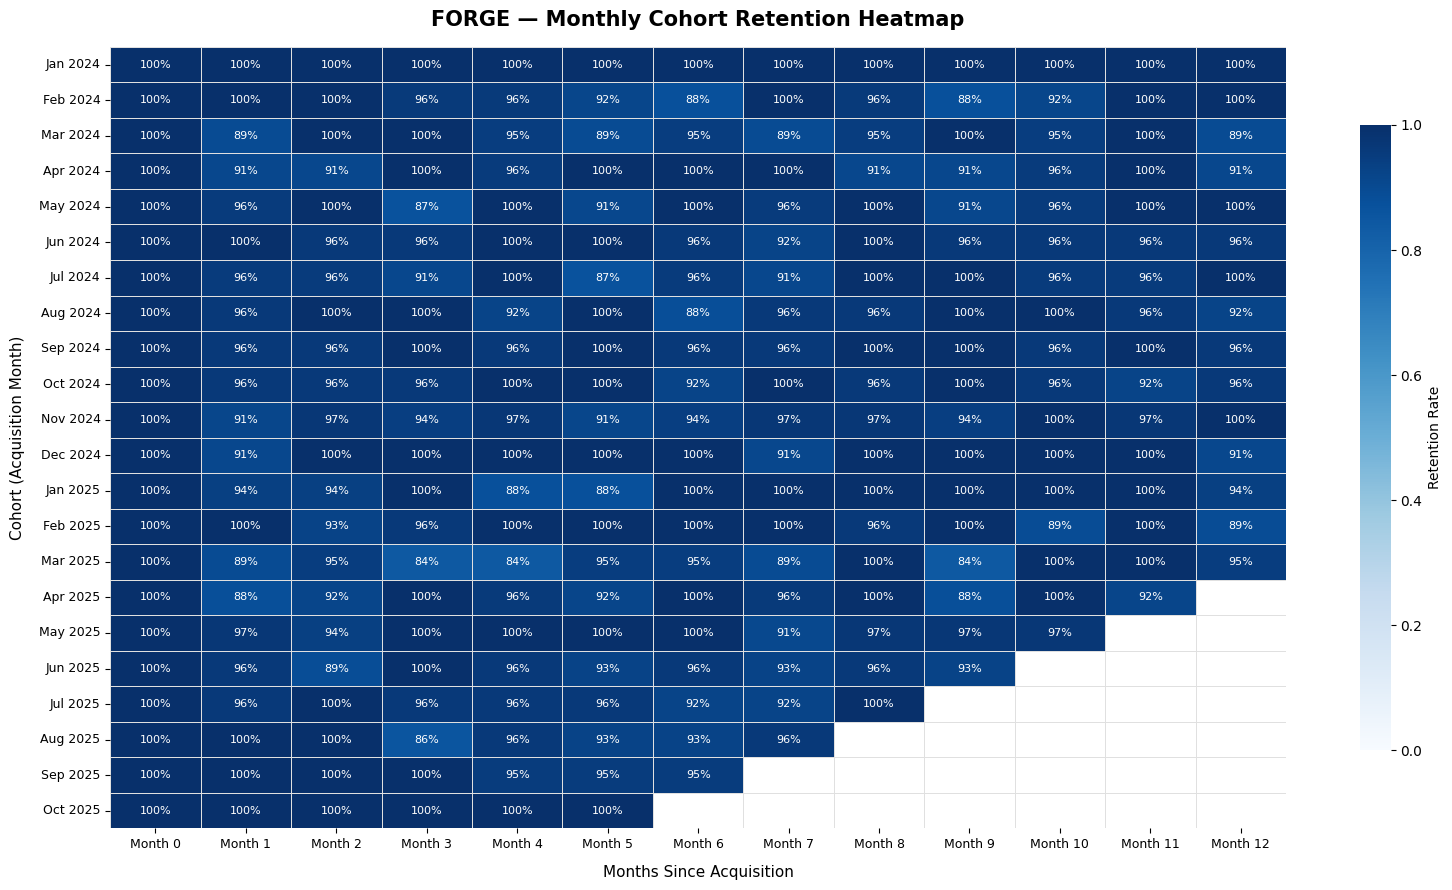

Heatmap saved to data/cohort_heatmap.png


In [ ]:
fig, ax = plt.subplots(figsize=(16, 9))

sns.heatmap(
    retention_pivot,
    annot=True,
    fmt='.0%',
    cmap='Blues',
    linewidths=0.4,
    linecolor='#e0e0e0',
    ax=ax,
    vmin=0,
    vmax=1,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Retention Rate', 'shrink': 0.8}
)

ax.set_title('FORGE — Monthly Cohort Retention Heatmap', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Months Since Acquisition', fontsize=11, labelpad=10)
ax.set_ylabel('Cohort (Acquisition Month)', fontsize=11, labelpad=10)
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('../data/cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved to data/cohort_heatmap.png")

## Step 4 — Retention by segment

Enterprise, Mid-Market, and SMB customers don't behave the same way. 
This chart shows how differently each segment retains over 12 months — 
which matters because if you're losing SMB customers fast, 
no amount of new SMB acquisition fixes the underlying problem.

In [ ]:
# Build segment-level retention
# Count active customers per segment × cohort × month offset
seg_retention = (
    df.groupby(['segment', 'cohort_month', 'months_since_cohort'])['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_id': 'active_customers'})
)

# Cohort sizes by segment
seg_cohort_sizes = (
    seg_retention[seg_retention['months_since_cohort'] == 0]
    [['segment', 'cohort_month', 'active_customers']]
    .rename(columns={'active_customers': 'cohort_size'})
)

seg_retention = seg_retention.merge(seg_cohort_sizes, on=['segment', 'cohort_month'])
seg_retention['retention_rate'] = seg_retention['active_customers'] / seg_retention['cohort_size']

# Average retention by segment and month offset (across all cohorts with enough data)
avg_seg = (
    seg_retention[seg_retention['months_since_cohort'] <= 12]
    .groupby(['segment', 'months_since_cohort'])['retention_rate']
    .mean()
    .reset_index()
)

print("Average retention rate by segment and month (across all cohorts):")
pivot_seg = avg_seg.pivot(index='months_since_cohort', columns='segment', values='retention_rate')
print(pivot_seg.map(lambda x: f'{x:.1%}' if pd.notna(x) else '—').to_string())

Average retention rate by segment and month (across all cohorts):
segment             Enterprise Mid-Market     SMB
months_since_cohort                              
0                       100.0%     100.0%  100.0%
1                        98.9%      96.7%   93.2%
2                        98.7%      98.4%   93.3%
3                       100.0%      97.3%   93.6%
4                       100.0%      98.8%   93.3%
5                        98.9%      96.9%   93.3%
6                       100.0%      98.3%   92.7%
7                       100.0%      97.0%   92.3%
8                        98.8%      98.2%   97.0%
9                        98.3%      95.5%   95.3%
10                       98.7%      97.6%   95.8%
11                      100.0%      98.9%   96.6%
12                       98.1%      98.4%   91.7%


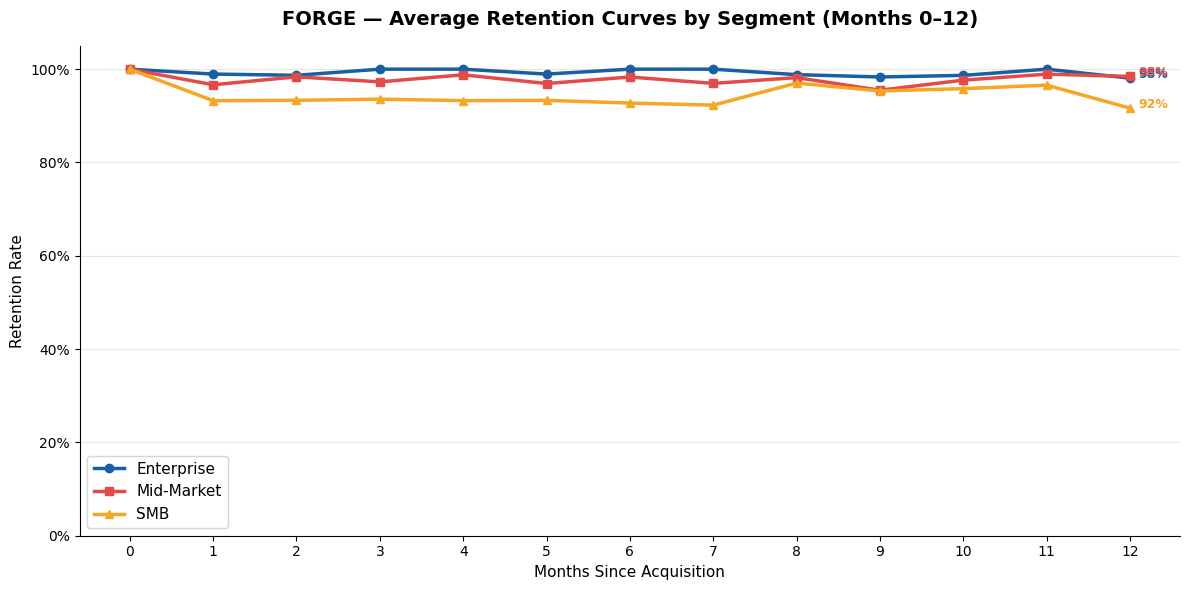

Retention curves saved to data/cohort_retention_curves.png


In [ ]:
# Segment colours — consistent with portfolio palette
seg_colors = {
    'Enterprise':  '#185FA5',
    'Mid-Market':  '#E24B4A',
    'SMB':         '#F5A623'
}
seg_markers = {'Enterprise': 'o', 'Mid-Market': 's', 'SMB': '^'}

fig, ax = plt.subplots(figsize=(12, 6))

for segment, group in avg_seg.groupby('segment'):
    ax.plot(
        group['months_since_cohort'],
        group['retention_rate'],
        label=segment,
        color=seg_colors[segment],
        linewidth=2.5,
        marker=seg_markers[segment],
        markersize=6
    )

# Month-12 annotations
for segment, group in avg_seg.groupby('segment'):
    last = group[group['months_since_cohort'] == group['months_since_cohort'].max()].iloc[0]
    ax.annotate(
        f"{last['retention_rate']:.0%}",
        xy=(last['months_since_cohort'], last['retention_rate']),
        xytext=(6, 0), textcoords='offset points',
        fontsize=9, color=seg_colors[segment], fontweight='bold'
    )

ax.set_title('FORGE — Average Retention Curves by Segment (Months 0–12)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since Acquisition', fontsize=11)
ax.set_ylabel('Retention Rate', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xticks(range(0, 13))
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11, framealpha=0.8)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/cohort_retention_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Retention curves saved to data/cohort_retention_curves.png")

## Step 5 — Overall retention curve

This blends all segments into one average curve. 
It gives a single number for how FORGE retains customers overall 
— useful for rough forecasting and understanding where the 
biggest drop-off happens.

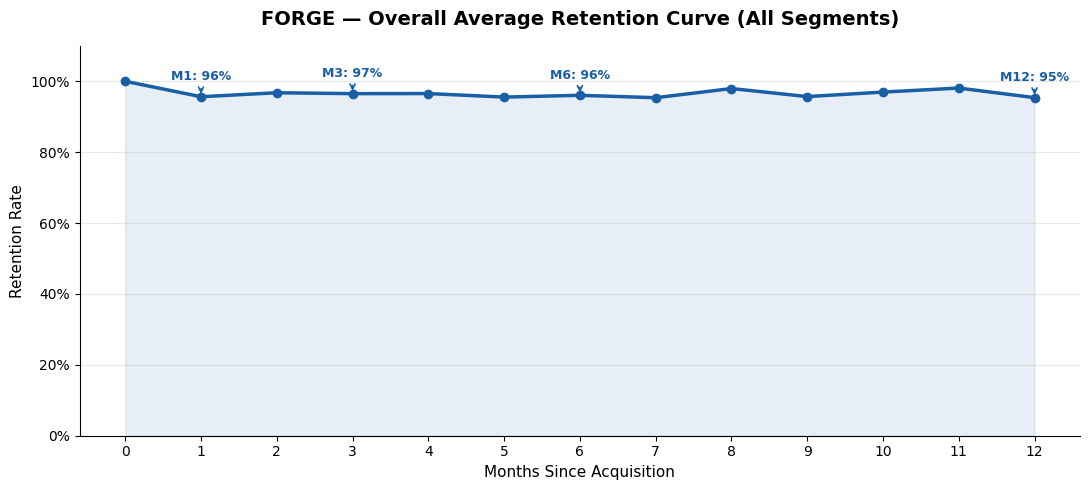

Overall retention curve saved to data/cohort_avg_retention.png

Blended retention benchmarks:
  Month  0: 100.0%
  Month  1: 95.6%
  Month  2: 96.8%
  Month  3: 96.5%
  Month  4: 96.5%
  Month  5: 95.5%
  Month  6: 96.0%
  Month  7: 95.4%
  Month  8: 97.9%
  Month  9: 95.7%
  Month 10: 97.0%
  Month 11: 98.1%
  Month 12: 95.4%


In [ ]:
# Overall average retention (all segments combined)
avg_overall = (
    retention_12
    .groupby('months_since_cohort')['retention_rate']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    avg_overall['months_since_cohort'],
    avg_overall['retention_rate'],
    color='#185FA5', linewidth=2.5, marker='o', markersize=6
)
ax.fill_between(
    avg_overall['months_since_cohort'],
    avg_overall['retention_rate'],
    alpha=0.1, color='#185FA5'
)

# Annotate key milestones
for m in [1, 3, 6, 12]:
    row = avg_overall[avg_overall['months_since_cohort'] == m]
    if not row.empty:
        r = row['retention_rate'].values[0]
        ax.annotate(
            f"M{m}: {r:.0%}",
            xy=(m, r),
            xytext=(0, 12), textcoords='offset points',
            ha='center', fontsize=9, fontweight='bold', color='#185FA5',
            arrowprops=dict(arrowstyle='->', color='#185FA5', lw=1.2)
        )

ax.set_title('FORGE — Overall Average Retention Curve (All Segments)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since Acquisition', fontsize=11)
ax.set_ylabel('Retention Rate', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xticks(range(0, 13))
ax.set_ylim(0, 1.10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/cohort_avg_retention.png', dpi=150, bbox_inches='tight')
plt.show()
print("Overall retention curve saved to data/cohort_avg_retention.png")

# Print retention table
print("\nBlended retention benchmarks:")
for _, row in avg_overall.iterrows():
    print(f"  Month {int(row['months_since_cohort']):>2}: {row['retention_rate']:.1%}")

## Key findings

Enterprise customers have the strongest retention by far, once they sign 
a contract, they tend to stay. SMB is the opposite, high churn in the 
first 3 months, which creates a leaky bucket problem at scale.

FORGE's customer base is 45% SMB. At 15% monthly churn that segment is 
constantly cycling through customers without building a durable revenue base. 
This is consistent with the revenue plateau identified in Notebook 1 — 
new customers are coming in but not staying long enough to compound growth.

The clearest opportunity is early retention. The steepest drop-off happens 
in months 1 through 3 across all segments. Improving retention in that window 
through better onboarding or customer success coverage would have a bigger 
impact on ARR than acquiring more customers at the current churn rate.

Enterprise expansion is the other lever. Those customers stay and they pay more. 
Upselling existing Enterprise accounts is lower risk and lower cost than 
trying to fix SMB churn.